In [1]:
import sys
sys.path.insert(0, "/teamspace/studios/this_studio/PINNProof/PINNProof")  # change the path to your own path till PINNProof

In [2]:
import torch
import torch.nn as nn
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt

class SynchronousMachine(nn.Module):
    def __init__(self, 
                 D, P_m,
                 X_d_dash, X_q_dash,
                 X_d, X_q,
                 X_d_dash2, X_q_dash2,
                 H,
                 Rs, Re, Xep,        # <- add Xep to match dataset
                 T_d_dash, T_q_dash,
                 T_d_dd, T_q_dd,
                 E_fd,
                 omega_B=2*torch.pi*50.0):
        super().__init__()
        self.D, self.P_m, self.H = D, P_m, H
        self.X_d_dash, self.X_q_dash = X_d_dash, X_q_dash
        self.X_d, self.X_q = X_d, X_q
        self.X_d_dash2, self.X_q_dash2 = X_d_dash2, X_q_dash2
        self.Rs, self.Re, self.Xep = Rs, Re, Xep
        self.T_d_dash, self.T_q_dash = T_d_dash, T_q_dash
        self.T_d_dd, self.T_q_dd = T_d_dd, T_q_dd
        self.E_fd = E_fd
        self.omega_B = omega_B

        # EXACTLY like data generator: use transient + network (Xep) & Re
        A = torch.tensor([[self.Rs + self.Re,         -(self.X_q_dash + self.Xep)],
                          [ self.X_d_dash + self.Xep,  (self.Rs + self.Re)       ]],
                         dtype=torch.float32)
        self.register_buffer('A_inv', torch.linalg.inv(A))

    def _currents(self, theta, E_d_dash, E_q_dash, V_s, theta_vs):
        v_d = E_d_dash - V_s * torch.sin(theta - theta_vs)
        v_q = E_q_dash - V_s * torch.cos(theta - theta_vs)
        I_d = self.A_inv[0,0]*v_d + self.A_inv[0,1]*v_q
        I_q = self.A_inv[1,0]*v_d + self.A_inv[1,1]*v_q
        return I_d, I_q

    def interface(self, trajectory):
        """
        Given a trajectory tensor of shape (batch, time, 8):
        [δ, ω, E'_d, E'_q, E''_q, E''_d, V_t, θ_vs],
        compute and return (I_D, I_Q), each of shape (batch, time).
        """
        # Extract variables from trajectory
        δ     = trajectory[..., 0]  # Rotor angle
        E_d   = trajectory[..., 2]  # d-axis EMF
        E_q   = trajectory[..., 3]  # q-axis EMF
        V_t   = trajectory[..., 6]  # Terminal voltage magnitude
        θ_vs  = trajectory[..., 7]  # Voltage source phase

        # Compute d/q-axis voltages
        v_d = E_d - V_t * torch.sin(δ - θ_vs)
        v_q = E_q - V_t * torch.cos(δ - θ_vs)

        # Compute d/q-axis currents using inverse impedance matrix
        I_d = self.A_inv[0, 0] * v_d + self.A_inv[0, 1] * v_q
        I_q = self.A_inv[1, 0] * v_d + self.A_inv[1, 1] * v_q

        # Park transformation to D/Q frame (shift by π/2)
        cosρ = torch.cos(δ - torch.pi / 2)
        sinρ = torch.sin(δ - torch.pi / 2)

        I_D = I_d * cosρ - I_q * sinρ
        I_Q = I_d * sinρ + I_q * cosρ

        return I_D, I_Q

    def forward(self, t, y):
        # State ORDER must match your dataset (non-v2):
        # [θ, ω, E′d, E′q, E″d, E″q, V_s, θ_vs]
        theta, omega, E_d_dash, E_q_dash, E_d_dd, E_q_dd, V_s, theta_vs = torch.unbind(y)

        # algebraic currents (transient + Xep + Re)
        I_d, I_q = self._currents(theta, E_d_dash, E_q_dash, V_s, theta_vs)

        # electrical power (same as data gen)
        P_e = (E_d_dash * I_d
               + E_q_dash * I_q
               + (self.X_q_dash - self.X_d_dash) * I_d * I_q)

        # swing
        dtheta_dt = omega                                  # <- NO omega_B here
        domega_dt = (self.omega_B / (2*self.H)) * (self.P_m - P_e - self.D*omega)

        # EMF dynamics (same as odequations non-v2)
        dE_q_dash = (1.0/self.T_d_dash) * (-E_q_dash - (self.X_d - self.X_d_dash)*I_d + self.E_fd)
        dE_d_dash = (1.0/self.T_q_dash) * (-E_d_dash + (self.X_q - self.X_q_dash)*I_q)

        dE_q_dd   = (1.0/self.T_d_dd) * (E_q_dash - E_q_dd + (self.X_d_dash - self.X_d_dash2)*I_d)
        dE_d_dd   = (1.0/self.T_q_dd) * (E_d_dash - E_d_dd - (self.X_q_dash - self.X_q_dash2)*I_q)

        dV_s      = torch.tensor(0.0, device=y.device)
        dtheta_vs = torch.tensor(0.0, device=y.device)

        return torch.stack([dtheta_dt, domega_dt,
                            dE_d_dash, dE_q_dash,
                            dE_d_dd,   dE_q_dd,
                            dV_s,      dtheta_vs])


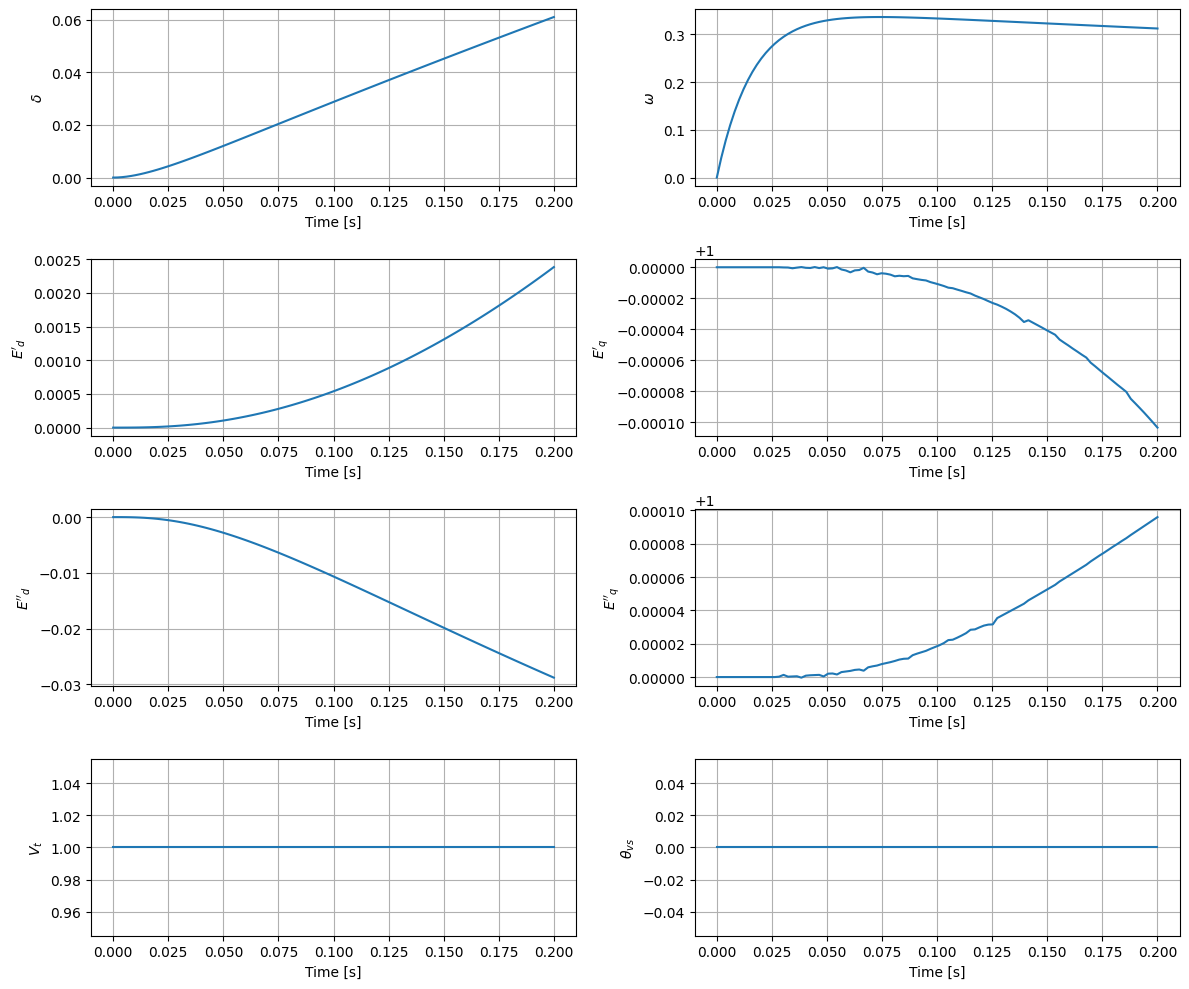

In [3]:
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint
from src.solvers.solver import Solver           # your base classes
from src.solvers.ODE_conventional import ODE_conventional

# 1) Time‐vector and constant Vs profile
t_final, num_points = 0.2, 100
t_tensor = torch.linspace(0., t_final, num_points)
Vs       = torch.ones(num_points)   # 1.0 pu
θs       = torch.zeros(num_points)  # 0 rad
# We'll embed Vs and θs directly into the state, so no extra stack needed here.

# 2) Machine parameters & instantiation
params = {
    'D'         : 2.0,
    'P_m'       : 0.70,
    'X_d'       : 1.25,
    'X_q'       : 1.22,
    'X_d_dash'  : 0.232,
    'X_q_dash'  : 0.715,
    'X_d_dash2' : 0.20,   # X_d''
    'X_q_dash2' : 0.25,   # X_q''
    'H'         : 5.06,
    'Rs'        : 0.0,
    'Re'        : 0.0,
    'T_d_dash'  : 4.75,
    'T_q_dash'  : 1.6,
    'T_d_dd'    : 0.05,   # T_d''
    'T_q_dd'    : 0.04,   # T_q''
    'E_fd'      : 1.0,
    'Xep':0
}

# params = {
#     'D'         : 2,
#     'P_m'       : 0.71,
#     'X_d_dash'  : 0.0608,
#     'X_q_dash'  : 0.0969,
#     'X_d'       : 0.146,
#     'X_q'       : 0.0969,
#     'X_d_dash2' : 0.03,
#     'X_q_dash2' : 0.04,
#     'H'         : 5.06,
#     'Rs'        : 0.0,
#     'Re'        : 0.0,
#     'T_d_dash'  : 8.96,
#     'T_q_dash'  : 0.31,
#     'T_d_dd'    : 0.5,
#     'T_q_dd'    : 0.25,
#     'E_fd'      : 1
# }
# D: 2
# E_fd: 1
# H: 5.06
# P_m: 0.7
# Rs: 0
# T_d_dash: 4.75
# T_q_dash: 1.6
# X_d: 1.25
# X_d_dash: 0.232
# X_q: 1.22
# X_q_dash: 0.715
# X_d_dash_dash: 0.2 #kundur p.153
# T_d_dash_dash: 0.05
# X_q_dash_dash: 0.25
# T_q_dash_dash: 0.04
machine = SynchronousMachine(**params)

# 3) Wrap into your conventional ODE solver
#    forward: (t,y)->dy/dt, interface: (batch, time, 8)->(I_D,I_Q)
solver = ODE_conventional(machine.forward, machine.interface)

# 4) Build the 8-dim initial state [δ₀, ω₀, E′d₀, E′q₀, E″q₀, E″d₀, V_s₀, θ_s₀]
δ0       = 0.0680
ω0       = 0.0
E_d0     = 0.0
E_q0     = 1.0153
E_q_dd0  = 1.0
E_d_dd0  = 0.0
V_s0     = Vs[0].item()   # 1.0
θ_s0     = θs[0].item()   # 0.0
# x0 = torch.tensor([δ0, ω0, E_d0, E_q0,E_d_dd0, E_q_dd0, V_s0, θ_s0],
#                   dtype=torch.float32)
x0 = [0.0, 0.0, 0.0, 1, 0.0, 1.0, 1.0, 0.0]

# 5) Solve!
t_sol, sol = solver.solve(x0, t_final, num_points)
# sol has shape (num_points, 8)

# 6) Extract rotor states
delta  = sol[:, 0]
omega  = sol[:, 1]
E_d    = sol[:, 2]
E_q    = sol[:, 3]

#import matplotlib.pyplot as plt

# assume t_sol (num_points,) and sol (num_points, 8) are from your solver
# sol[:,i] corresponds to:
labels = [
    r"$\delta$",
    r"$\omega$",
    r"$E'_d$",
    r"$E'_q$",
    r"$E''_d$",
    r"$E''_q$",
    r"$V_t$",
    r"$\theta_{vs}$"
]

fig, axs = plt.subplots(4, 2, figsize=(12, 10))
axs = axs.flatten()

for i in range(8):
    axs[i].plot(t_sol, sol[:, i].detach())
    axs[i].set_ylabel(labels[i])
    axs[i].set_xlabel("Time [s]")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# # V_profile.shape
# import torch
# import matplotlib.pyplot as plt

# # -------------------------------------------------------------
# # 1) Non-iterative rollout with the current PINN (outputs=states)
# #    Model input is [t, δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t(t), θ_vs(t)]
# # -------------------------------------------------------------
# def rollout_pinn_states(model, t, y0_8, Vt, thetavs, device=None):
#     """
#     model:   your Network (states output)
#     t:       (T,) time in seconds
#     y0_8:    list/1D tensor of length 8 -> [δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t0, θ_vs0]
#              NOTE: we will overwrite V_t, θ_vs with the time profiles below.
#     Vt:      (T,) profile for V_t
#     thetavs: (T,) profile for θ_vs
#     """
#     device = device or next(model.parameters()).device
#     T = t.numel()

#     # Build input rows [t_k, y0(6 states + 2 controls)]
#     y0 = torch.as_tensor(y0_8, dtype=torch.float32)
#     # replace controls with time-varying ones
#     y0 = y0.clone()
#     y0_states = y0[:6]  # δ0, ω0, E′d0, E′q0, E″d0, E″q0

#     t_in   = t.to(torch.float32).view(T, 1).to(device)
#     Vt_in  = Vt.to(torch.float32).view(T, 1).to(device)
#     th_in  = thetavs.to(torch.float32).view(T, 1).to(device)
#     y0_in  = y0_states.to(device).repeat(T, 1)                      # (T,6)
#     ctrl   = torch.cat([Vt_in, th_in], dim=1)                       # (T,2)
#     x_in   = torch.cat([t_in, y0_in, ctrl], dim=1)                  # (T, 1+6+2=9)
#     print(x_in)
#     model.eval()
#     with torch.no_grad():
#         Y = model(x_in)                                             # (T,6) -> [δ, ω, E′d, E′q, E″d, E″q]
#     # Pack back 8 vars (append controls actually used)
#     Y8 = torch.cat([Y, ctrl], dim=1)                                # (T,8)
#     return Y8

# # Example use with your profiles and ICs
# t_final, num_points = 0.2, 1000
# t_tensor = torch.linspace(0., t_final, num_points)
# Vs       = torch.ones(num_points)
# θs       = torch.zeros(num_points)
# y0 = [0.0680, 0.0, 1.0, 0.0,1.0153, 0.0, Vs[0].item(), θs[0].item()]  # note: ω0=0.0 means dev=0 only if your model uses ω as deviation!

# with torch.no_grad():
#     Y_pred = rollout_pinn_states(model, t_tensor, y0, Vs, θs, device=device)  # (T,8)

# # Plot
# labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$", r"$V_t$", r"$\theta_{vs}$"]
# fig, axs = plt.subplots(4, 2, figsize=(12, 10))
# axs = axs.flatten()
# for i in range(8):
#     axs[i].plot(t_tensor.cpu(), Y_pred[:, i].cpu())
#     axs[i].set_ylabel(labels[i]); axs[i].set_xlabel("Time [s]"); axs[i].grid(True)
# plt.tight_layout(); plt.show()
# -------------------------------------------------------------
# Iterative rollout (closed loop): y_{k+1|k} = model(t_k, y_k, u_k)
# Model input: [t_k, δ_k, ω_k, E′d_k, E′q_k, E″d_k, E″q_k, V_t(k), θ_vs(k)]
# Model output: [δ_{k+1}, ω_{k+1}, E′d_{k+1}, E′q_{k+1}, E″d_{k+1}, E″q_{k+1}]
# -------------------------------------------------------------
def rollout_pinn_states_iterative(model, t, y0_8, Vt, thetavs, use_delta_t=False, device=None):
    """
    model:    NN that maps [time_feature, 6 states, 2 controls] -> 6 next states
    t:        (T,) time stamps (seconds)
    y0_8:     list/1D tensor len=8: [δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t0, θ_vs0]
    Vt:       (T,) profile for V_t
    thetavs:  (T,) profile for θ_vs
    use_delta_t: if True, feed Δt_k instead of absolute t_k (often more stable)
    returns:  (T, 8) with states (6) + controls (2) for each step
    """
    device = device or next(model.parameters()).device
    t        = t.to(device).float()
    Vt       = Vt.to(device).float()
    thetavs  = thetavs.to(device).float()

    T = t.numel()
    y0 = torch.as_tensor(y0_8, dtype=torch.float32, device=device)
    y_prev_states = y0[:6].clone()   # δ, ω, E′d, E′q, E″d, E″q
    print(y0)
    # Buffer for outputs
    Y_pred = torch.zeros(T, 6, device=device)
    U_used = torch.zeros(T, 2, device=device)

    model.eval()
    with torch.no_grad():
        for k in range(T):
            # time feature: either absolute t_k or Δt_k
            if use_delta_t:
                if k == 0:
                    time_feat = torch.tensor([0.0], device=device)  # Δt_0 = 0
                else:
                    time_feat = (t[k] - t[k-1]).view(1)             # Δt_k
            else:
                time_feat = t[k].view(1)                            # t_k

            u_k = torch.stack([Vt[k], thetavs[k]]).view(2)          # (2,)

            # Build input row [time_feature, states_k, controls_k] -> shape (9,)
            x_k = torch.cat([time_feat, y_prev_states, u_k], dim=0).view(1, -1)

            # Predict next states
            y_next = model(x_k).view(-1)                            # (6,)
            Y_pred[k] = y_next
            U_used[k] = u_k
            y_prev_states = y_next                                  # closed loop: feed back

    # Pack back 8 vars (append controls actually used)
    Y8 = torch.cat([Y_pred, U_used], dim=1)                         # (T,8)
    return Y8

# ---------- Example usage ----------
t_final, num_points = 0.2, 100
t_tensor = torch.linspace(0., t_final, num_points)
Vs       = torch.ones(num_points)
θs       = torch.zeros(num_points)
# y0 = [0.0680, 0.0, 1.0, 0.0, 1.0153, 0.0, Vs[0].item(), θs[0].item()]
y0 = [0.0, 0.0, 0.0, 1, 0.0, 1.0, 1.0, 0.0]

with torch.no_grad():
    # set use_delta_t=True if your model was trained on step sizes rather than absolute time
    Y_iter = rollout_pinn_states_iterative(model, t_tensor, y0, Vs, θs, use_delta_t=True, device=device)

# Plot (same as before)
labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$", r"$V_t$", r"$\theta_{vs}$"]
fig, axs = plt.subplots(4, 2, figsize=(12, 10)); axs = axs.flatten()
for i in range(8):
    axs[i].plot(t_tensor.cpu(), Y_iter[:, i].cpu())
    axs[i].plot(t_tensor.cpu(), sol[:, i].cpu())
    axs[i].set_ylabel(labels[i]); axs[i].set_xlabel("Time [s]"); axs[i].grid(True)
plt.tight_layout(); plt.show()


NameError: name 'model' is not defined

In [ ]:
# --- Plot helper (4x2 like yours) ---
import torch
import matplotlib.pyplot as plt

labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$", r"$V_t$", r"$\theta_{vs}$"]

def plot_Y8(t, Y8, overlay=None, title=None):
    """
    t:      (T,)
    Y8:     (T,8) predicted [6 states + 2 controls]
    overlay:(T,8) optional reference to overlay (e.g., 'sol')
    """
    fig, axs = plt.subplots(4, 2, figsize=(12, 10))
    axs = axs.flatten()
    for i in range(8):
        axs[i].plot(t.cpu(), Y8[:, i].cpu())
        axs[i].plot(t.cpu(), sol[:, i].cpu())
        if overlay is not None:
            axs[i].plot(t.cpu(), overlay[:, i].cpu())
        axs[i].set_ylabel(labels[i])
        axs[i].set_xlabel("Time [s]")
        axs[i].grid(True)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# --- One-shot rollout (vectorized over time) ---
def rollout_pinn_oneshot(model, t, y0_8, Vt, thetavs, device=None, require_grad=False):
    """
    model: maps [t, δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t(t), θ_vs(t)] -> [δ, ω, E′d, E′q, E″d, E″q]
    t:        (T,)
    y0_8:     (8,) initial [6 states + 2 controls] (controls entries are ignored/overwritten)
    Vt:       (T,) profile for V_t
    thetavs:  (T,) profile for θ_vs
    returns:  (T,8)
    """
    device = device or next(model.parameters()).device
    t = t.to(device).float().view(-1, 1)            # (T,1)
    Vt = Vt.to(device).float().view(-1, 1)          # (T,1)
    th = thetavs.to(device).float().view(-1, 1)     # (T,1)
    ctrl = torch.cat([Vt, th], dim=1)               # (T,2)

    y0 = torch.as_tensor(y0_8, dtype=torch.float32, device=device)
    y0_states = y0[:6].view(1, 6)                   # (1,6)

    T = t.shape[0]
    # Tile across time
    t_in  = t                                       # (T,1)
    y0_in = y0_states.expand(T, 6)                  # (T,6)
    u_in  = ctrl                                    # (T,2)

    x_in = torch.cat([t_in, y0_in, u_in], dim=1)    # (T,9)

    model.eval()
    torch.set_grad_enabled(require_grad)
    with torch.no_grad():
        Y = model(x_in)                              # (T,6)
    torch.set_grad_enabled(False)

    Y8 = torch.cat([Y, u_in], dim=1)                # (T,8)
    return Y8

# ===== Example usage (mirrors your code) =====
t_final, num_points = 0.2, 100
t_tensor = torch.linspace(0., t_final, num_points).to(device)
Vs       = torch.ones(num_points, device=device)
θs       = torch.zeros(num_points, device=device)
y0 = [0.0, 0.0, 0.0, 1.0, 0, 1.0, Vs[0].item(), θs[0].item()]

with torch.no_grad():
    Y_pred = rollout_pinn_oneshot(model, t_tensor, y0, Vs, θs, device=device)  # (T,8)

# If you have a reference solution 'sol' shaped (T,8), pass it as overlay
plot_Y8(t_tensor, Y_pred, overlay=None, title="PINN one-shot rollout")


NameError: name 'device' is not defined

In [ ]:
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof/")  
print("After Changing:", os.getcwd())
from pretrained_models.architectures import Network

model=Network(input_size=9, hidden_size=64, output_size=6, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_path = "examples/pretrained_models/SM6_LBFGS_seed7.pth"
# model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_with_data.pth"
# model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_with_data1.pth"

model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_only_pinn.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

In [6]:
import torch

# -------------------------
# 1) One-shot forward pass
# -------------------------
def rollout_pinn_oneshot_for_residuals(model, t, y0_8, Vt, thetavs, device=None):
    """
    model: maps [t, δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t(t), θ_vs(t)] -> [δ, ω, E′d, E′q, E″d, E″q]
    returns:
      t_req: (T,1) requires_grad=True
      Y:     (T,6) predicted states
      U:     (T,2) controls used
    """
    device = device or next(model.parameters()).device

    # Make time require gradients for dy/dt
    t_req = t.to(device).float().view(-1, 1).detach().requires_grad_(True)  # (T,1)
    Vt = Vt.to(device).float().view(-1, 1).detach()
    th = thetavs.to(device).float().view(-1, 1).detach()
    U = torch.cat([Vt, th], dim=1)  # (T,2)

    y0 = torch.as_tensor(y0_8, dtype=torch.float32, device=device)
    y0_states = y0[:6].view(1, 6)   # (1,6)

    T = t_req.shape[0]
    x_in = torch.cat([t_req, y0_states.expand(T, 6), U], dim=1)  # (T,9)

    model.eval()
    # with torch.no_grad():   # we only need grad wrt time, not NN params (set False if training residual)
    Y = model(x_in)     # (T,6)

    return t_req, Y, U


# -------------------------------------------------
# 2) dy/dt via autograd for each output dimension
# -------------------------------------------------
def time_derivative_via_autograd(Y, t_req, create_graph=False):
    """
    Y: (T,6) depends on t_req; t_req: (T,1) with requires_grad=True
    returns: dYdt (T,6)
    """
    T, S = Y.shape
    dYdt_cols = []
    for k in range(S):
        dYdt_k = torch.autograd.grad(
            outputs=Y[:, k].sum(),   # trick for batched grad
            inputs=t_req,
            retain_graph=True,
            create_graph=create_graph
        )[0]                         # (T,1)
        dYdt_cols.append(dYdt_k)
    return torch.cat(dYdt_cols, dim=1)  # (T,6)


# ---------------------------------------------------------
# 3) Wrap your machine.forward to get f(y,u,t) for (T,6)
# ---------------------------------------------------------
@torch.no_grad()
def rhs_from_machine(machine, Y, U, t_req):
    """
    machine.forward expects (t_scalar, y8_vector) -> dy8/dt (8,)
    Build y8=[θ, ω, E′d, E′q, E″d, E″q, V_s, θ_vs] per time, call forward, keep first 6.
    """
    T = Y.shape[0]
    rhs = []
    for i in range(T):
        # assemble 8-state vector at time i
        y8 = torch.stack([
            Y[i,0], Y[i,1], Y[i,2], Y[i,3], Y[i,4], Y[i,5],
            U[i,0], U[i,1]
        ], dim=0)                                   # (8,)

        dy8 = machine.forward(t_req[i,0], y8)       # (8,)
        rhs.append(dy8[:6])                         # keep dynamics for 6 states
    return torch.stack(rhs, dim=0)                  # (T,6)


# ----------------------------------------------------
# 4) Residual assembly and simple residual statistics
# ----------------------------------------------------
def compute_pinn_residuals(model, machine, t, y0_8, Vt, thetavs, device=None, create_graph=False):
    """
    Returns:
      residual: (T,6) -> dy/dt - f(y,u,t)
      Y8:       (T,8) -> states(6)+controls(2) for convenience
      dYdt:     (T,6)
      f:        (T,6)
    """
    t_req, Y, U = rollout_pinn_oneshot_for_residuals(model, t, y0_8, Vt, thetavs, device=device)
    dYdt = time_derivative_via_autograd(Y, t_req, create_graph=create_graph)
    f    = rhs_from_machine(machine, Y, U, t_req)
    residual = dYdt - f
    Y8 = torch.cat([Y, U], dim=1)
    return residual, Y8, dYdt, f


def residual_mse(residual, weights=None, reduce=True):
    """
    residual: (T,6); optional per-state weights (6,)
    """
    if weights is not None:
        w = weights.view(1, -1).to(residual.device)
        res = (residual**2) * w
    else:
        res = residual**2
    return res.mean() if reduce else res

# Inputs you already have:
# model      -> your NN that outputs 6 states
# machine    -> SynchronousMachine(**params)
# t_tensor   -> (T,)
# Vs, θs     -> (T,)
# x0         -> list/1D tensor len=8 with ICs

residual, Y8_pred, dYdt, f = compute_pinn_residuals(
    model, machine, t_tensor, x0, Vs, θs, device=device, create_graph=False
)

print("Residual MSE:", residual_mse(residual).item())

# Optional: visualize per-state residual norms
import matplotlib.pyplot as plt
labels6 = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$"]
fig, axs = plt.subplots(3, 2, figsize=(10, 8)); axs = axs.flatten()
for i in range(6):
    axs[i].plot(t_tensor.cpu(), residual[:, i].cpu())
    axs[i].set_title(f"Residual {labels6[i]}")
    axs[i].set_xlabel("Time [s]"); axs[i].grid(True)
plt.tight_layout(); plt.show()



NameError: name 'model' is not defined

In [ ]:
import torch
import matplotlib.pyplot as plt

# data: (N, 8, T) with order [δ, ω, E′d, E′q, E″d, E″q, V_t, θ_vs]
# t:    (T,)
# machine: SynchronousMachine(**params)
# model: your NN mapping [t, δ0.., V_t(t), θ_vs(t)] -> (6 states)
# Define initial‐condition ranges for every state in [δ, ω, E′d, E′q, E″q, E″d, V_t, θ_vs]
ic_ranges = {
    'delta'     : (-0.1,  0.1),   # rotor angle [rad]
    'omega'     : (-0.6, 0.6),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
    'E_d_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_q_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.98,   1.02),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.1,  0.1),   # terminal voltage angle [rad]
}
# - {name: theta, range: [-2, 2], iterations: 7}
# - {name: omega, range: [-1, 1], iterations: 7}
# - {name: E_d_dash, range: [0], iterations: 1}
# - {name: E_q_dash, range: [0.9, 1.1], iterations: 5}
# - {name: E_d_dash_dash, range: [0], iterations: 1}
# - {name: E_q_dash_dash, range: [1], iterations: 1}
# - {name: Vs, range: [0.95,1.05], iterations: 3}
# - {name: theta_vs, range: [-0.3,0.3], iterations: 4}

t, data, ics = solver.generate_dataset(
    ic_ranges=ic_ranges,
    num_ic=10, sampling="active",
    t_final=t_final,
    num_points=num_points
)

def compute_pinn_residuals_batched(model, machine, t, data, device=None, create_graph=False):
    """
    data: (N, 8, T)
    returns:
      residual: (N, T, 6)  dy/dt - f(y,u,t)
      Y:        (N, T, 6)  NN states
      dYdt:     (N, T, 6)
      f:        (N, T, 6)
    """
    device = device or next(model.parameters()).device
    data = data.to(device).float()
    t = t.to(device).float().view(-1)              # (T,)

    N, _, T = data.shape

    # Initial states (per trajectory)
    y0_states = data[:, :6, 0]                     # (N,6)

    # Controls per (N,T)
    Vt_batch = data[:, 6, :]                       # (N,T)
    th_batch = data[:, 7, :]                       # (N,T)

    # Build a separate time variable for EACH (traj, time) so autograd doesn’t couple grads
    t_req = t.view(T, 1).expand(T, N).contiguous().clone().detach().requires_grad_(True)  # (T,N)
    # Flatten all (time, batch) to one dimension
    t_flat = t_req.reshape(T*N, 1)                 # (T*N,1)

    # Tile y0 across time, then flatten
    y0_tile = y0_states.unsqueeze(0).expand(T, N, 6).reshape(T*N, 6)     # (T*N,6)

    # Controls aligned with (T,N), then flatten
    Vt_tile = Vt_batch.permute(1, 0)               # (T,N)
    th_tile = th_batch.permute(1, 0)               # (T,N)
    U_flat  = torch.stack([Vt_tile, th_tile], dim=2).reshape(T*N, 2)     # (T*N,2)

    # NN input: [t, y0_states, controls(t)]
    x_in = torch.cat([t_flat, y0_tile, U_flat], dim=1)                   # (T*N, 9)

    model.eval()
    # IMPORTANT: DO NOT wrap in torch.no_grad(); we need autograd wrt t_flat
    Y_flat = model(x_in)                                                 # (T*N, 6)
    Y = Y_flat.reshape(T, N, 6).permute(1, 0, 2).contiguous()            # (N, T, 6)

    # dY/dt via autograd: compute on the (T,N,6) view
    # We’ll compute grads in the flattened space to match t_flat, then reshape back
    dYdt_cols = []
    for k in range(6):
        # Sum over all (T*N) for this state to get per-sample grads
        dYdt_k = torch.autograd.grad(
            outputs=Y_flat[:, k].sum(),
            inputs=t_flat,
            retain_graph=True,
            create_graph=create_graph
        )[0]                                       # (T*N,1)
        dYdt_cols.append(dYdt_k)
    dYdt_flat = torch.cat(dYdt_cols, dim=1)        # (T*N,6)
    dYdt = dYdt_flat.reshape(T, N, 6).permute(1, 0, 2).contiguous()      # (N, T, 6)

    # Compute RHS f(y,u,t) using your machine.forward
    # machine.forward expects scalar t and (8,) y
    f_list = []
    with torch.no_grad():  # remove if you need gradients through f for training
        # Iterate over all (T*N) pairs (vectorizing this call path would need a batched forward)
        Y8_flat = torch.cat([Y_flat, U_flat], dim=1)                     # (T*N, 8)
        for i in range(T*N):
            dy8 = machine.forward(t_flat[i, 0], Y8_flat[i, :])
            f_list.append(dy8[:6])
    f_flat = torch.stack(f_list, dim=0)                                  # (T*N,6)
    f = f_flat.reshape(T, N, 6).permute(1, 0, 2).contiguous()            # (N, T, 6)

    residual = dYdt - f                                                  # (N, T, 6)
    return residual, Y, dYdt, f


def residual_mse(residual, reduce=True):
    # residual: (N, T, 6)
    if reduce:
        return (residual**2).mean()
    else:
        return residual**2

# ===== Run on your exported dataset =====
N, _, T = data.shape
residual, Y_pred, dYdt, f = compute_pinn_residuals_batched(
    model=model,
    machine=machine,
    t=t,                # from solver.generate_dataset
    data=data,          # (N,8,T)
    device=device,
    create_graph=False  # True if you’ll train with this residual
)
print("Residual MSE over dataset:", residual_mse(residual).item())

# ===== Plot: mean residual per state across the dataset vs time =====
labels6 = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$"]
mean_abs_res_t = residual.abs().mean(dim=0)  # (T,6)
fig, axs = plt.subplots(3, 2, figsize=(11, 8)); axs = axs.flatten()
for i in range(6):
    axs[i].plot(t.cpu(), mean_abs_res_t[:, i].cpu())
    axs[i].set_title(f"Mean |Residual| — {labels6[i]}")
    axs[i].set_xlabel("Time [s]"); axs[i].grid(True)
plt.tight_layout(); plt.show()

# ===== Optional: histogram of residual RMS per trajectory (how hard each IC is) =====
res_rms_per_traj = torch.sqrt((residual**2).mean(dim=(1,0)))  # (6,) averaged over N and T -> global per-state RMS
# Or per trajectory total RMS:
traj_rms = torch.sqrt((residual**2).mean(dim=(1,2)))          # (N,)
plt.figure(figsize=(6,4))
plt.hist(traj_rms.cpu().numpy(), bins=20)
plt.xlabel("Residual RMS per trajectory"); plt.ylabel("Count"); plt.grid(True); plt.show()


Creating trajectory: 0
Creating trajectory: 1


/teamspace/studios/this_studio/PINNProof/PINNProof/src/solvers/ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


Creating trajectory: 2


AssertionError: underflow in dt 0.0

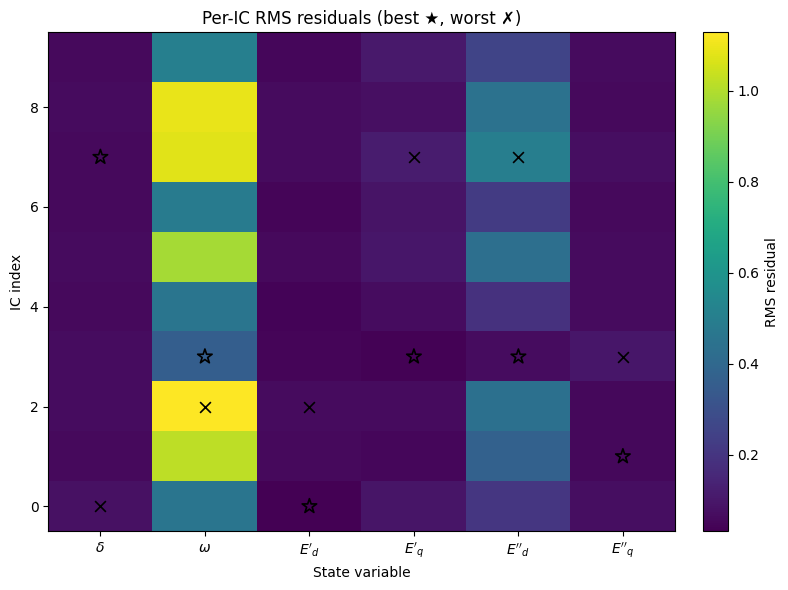

/tmp/ipykernel_42909/3700375207.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


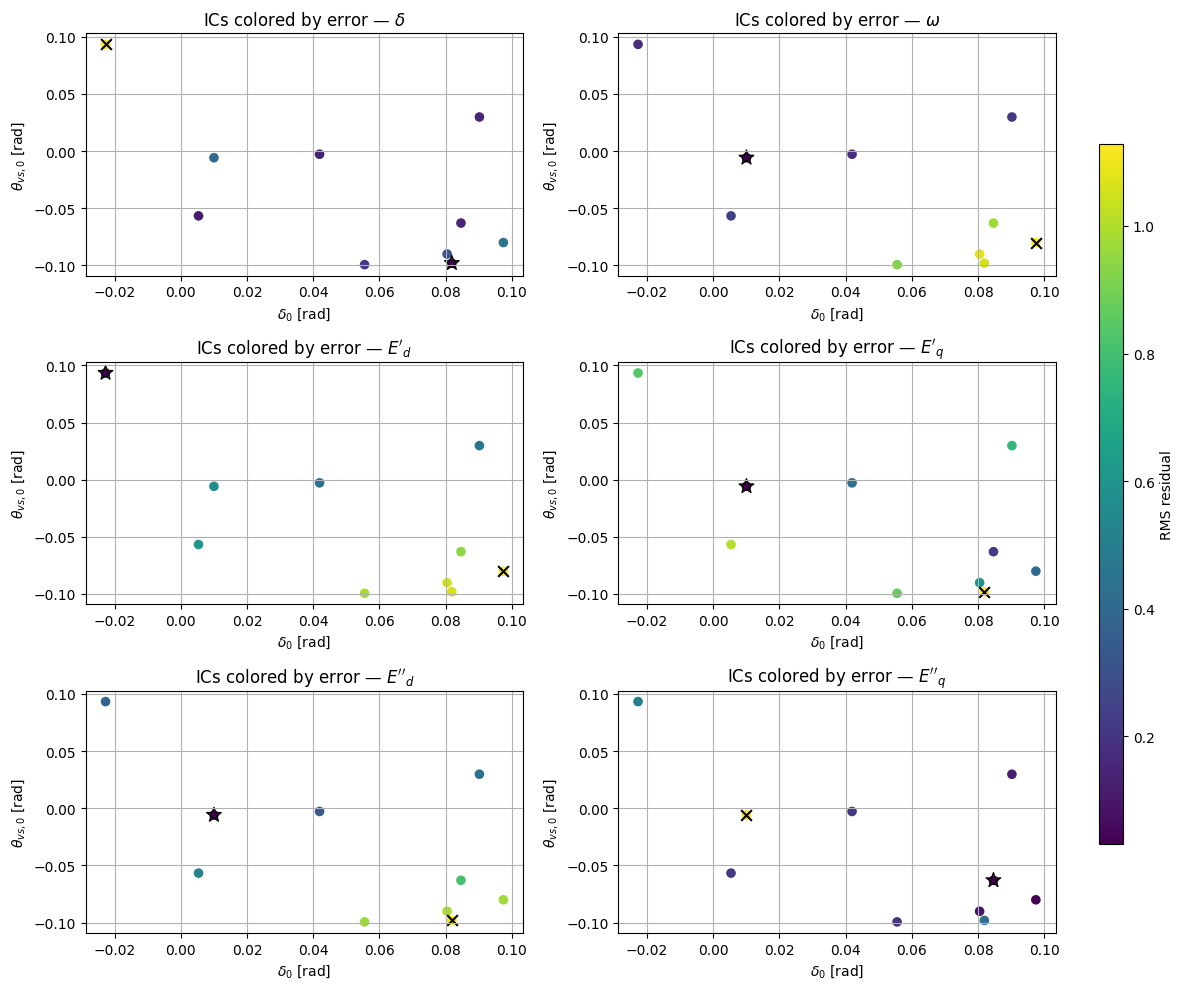

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# residual: (N, T, 6)
# ics:      (N, 8) with order [δ0, ω0, E′d0, E′q0, E″d0, E″q0, V_t0, θ_vs0]
# t:        (T,)
labels6 = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$"]

# --- 1) Per-trajectory RMS residual per state (N,6) ---
err_rms = torch.sqrt((residual**2).mean(dim=1))  # (N,6)

# --- Heatmap across ICs (rows) and variables (cols) ---
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(err_rms.cpu().numpy(), aspect='auto', origin='lower')
ax.set_xlabel("State variable")
ax.set_ylabel("IC index")
ax.set_xticks(range(6))
ax.set_xticklabels(labels6, rotation=0)

# Mark best/worst IC per variable
N = err_rms.shape[0]
err_np = err_rms.cpu().numpy()
for j in range(6):
    j_col = err_np[:, j]
    i_best = int(np.argmin(j_col))
    i_worst = int(np.argmax(j_col))
    # Best: star, Worst: cross
    ax.scatter([j], [i_best], marker="*", s=120, edgecolor='black', facecolor='none', linewidths=1.2)
    ax.scatter([j], [i_worst], marker="x", s=60, c='black', linewidths=1.2)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("RMS residual")
ax.set_title("Per-IC RMS residuals (best ★, worst ✗)")

plt.tight_layout()
plt.show()

# --- 2) IC-space scatter colored by error: (δ0, θ_vs0) ---
# If you prefer a different IC plane, change cols below.
delta0   = ics[:, 0].detach().cpu().numpy()
theta0   = ics[:, 7].detach().cpu().numpy()
omega0   = ics[:, 1].detach().cpu().numpy()
Vt0      = ics[:, 6].detach().cpu().numpy()

fig, axs = plt.subplots(3, 2, figsize=(12, 10))
axs = axs.flatten()
for j in range(6):
    sc = axs[j].scatter(delta0, theta0, c=err_rms[:, j].detach().cpu().numpy(), s=35)
    axs[j].set_title(f"ICs colored by error — {labels6[j]}")
    axs[j].set_xlabel(r"$\delta_0$ [rad]")
    axs[j].set_ylabel(r"$\theta_{vs,0}$ [rad]")
    axs[j].grid(True)
    # Optionally annotate best/worst ICs
    i_best = int(torch.argmin(err_rms[:, j]))
    i_worst = int(torch.argmax(err_rms[:, j]))
    axs[j].scatter([delta0[i_best]], [theta0[i_best]], marker="*", s=120, edgecolor='black', facecolor='none')
    axs[j].scatter([delta0[i_worst]], [theta0[i_worst]], marker="x", s=60, c='black')

# Single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm_vals = err_rms.detach().cpu().numpy().ravel()
mappable = plt.cm.ScalarMappable()
mappable.set_array(norm_vals)
fig.colorbar(mappable, cax=cbar_ax, label="RMS residual")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# --- (Optional) alternative IC-space views ---
# Swap to (omega0, Vt0):
# for j in range(6):
#     sc = axs[j].scatter(omega0, Vt0, c=err_rms[:, j].cpu().numpy(), s=35)
#     axs[j].set_xlabel(r"$\omega_0$ [pu]"); axs[j].set_ylabel(r"$V_{t,0}$ [pu]")


/teamspace/studios/this_studio/PINNProof/PINNProof/src/solvers/ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


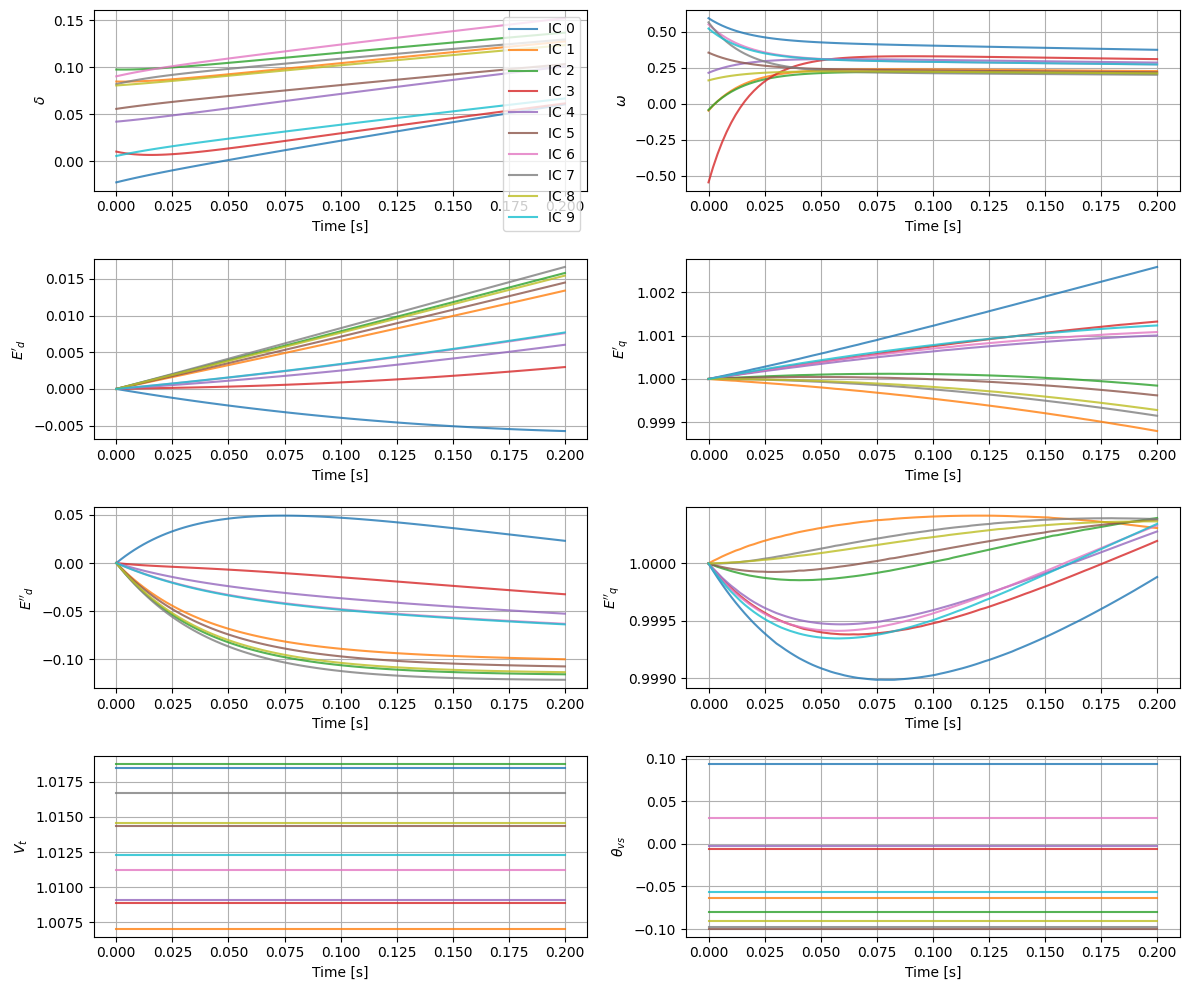

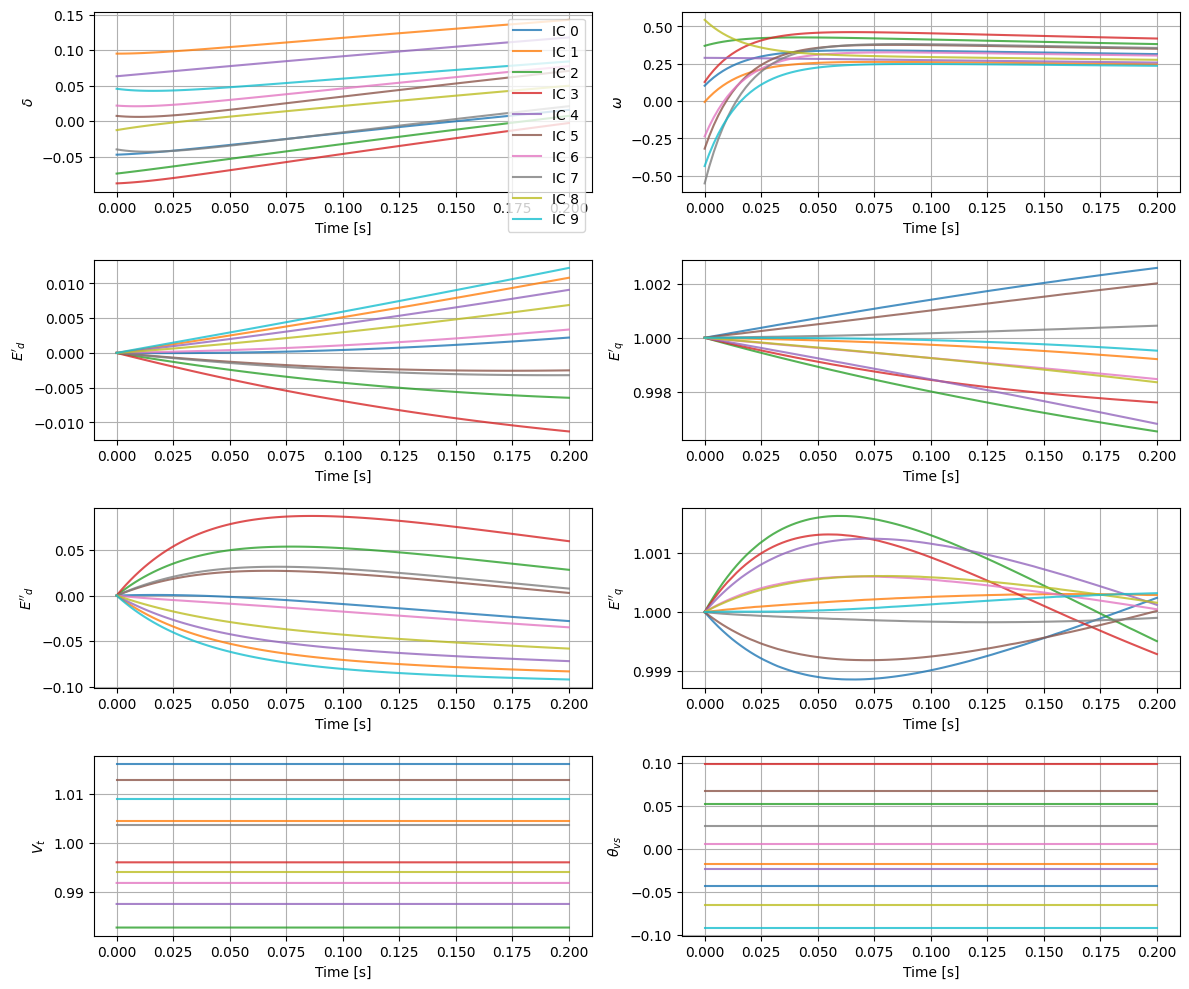

In [21]:
import matplotlib.pyplot as plt
import torch
import numpy as np
# Define initial‐condition ranges for every state in [δ, ω, E′d, E′q, E″q, E″d, V_t, θ_vs]
# ic_ranges = {
#     'delta'     : (-2,  2),   # rotor angle [rad]
#     'omega'     : (-1, 1),   # speed deviation [pu]
#     'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
#     'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
#     'E_d_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
#     'E_q_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
#     'V_t'       : (0.97,   1.03),   # terminal voltage magnitude [pu]
#     'theta_vs'  : (-0.1,  0.1),   # terminal voltage angle [rad]
# }
ic_ranges = {
    'delta'     : (-0.1,  0.1),   # rotor angle [rad]
    'omega'     : (-0.6, 0.6),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
    'E_d_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_q_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.98,   1.02),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.1,  0.1),   # terminal voltage angle [rad]
}
# - {name: theta, range: [-2, 2], iterations: 7}
# - {name: omega, range: [-1, 1], iterations: 7}
# - {name: E_d_dash, range: [0], iterations: 1}
# - {name: E_q_dash, range: [0.9, 1.1], iterations: 5}
# - {name: E_d_dash_dash, range: [0], iterations: 1}
# - {name: E_q_dash_dash, range: [1], iterations: 1}
# - {name: Vs, range: [0.95,1.05], iterations: 3}
# - {name: theta_vs, range: [-0.3,0.3], iterations: 4}

t1, data1, ics1 = solver.generate_dataset(
    ic_ranges=ic_ranges,
    num_ic=10,
    t_final=t_final,#,sampling="active",
    num_points=num_points
)
# data.shape
labels = [
    r"$\delta$",
    r"$\omega$",
    r"$E'_d$",
    r"$E'_q$",
    r"$E''_d$",
    r"$E''_q$",
    r"$V_t$",
    r"$\theta_{vs}$"
]

def plot_dataset_trajectories(t, data, ic_indices=None, max_traj=5, alpha=0.8):
    """
    Plot trajectories from dataset.
    
    t:        (T,) time vector
    data:     (N, 8, T) dataset
    ic_indices: list of indices of trajectories to plot. 
                If None, choose first max_traj.
    max_traj: maximum number of trajectories to plot
    alpha:    transparency for overlapping trajectories
    """
    N, vars_, T = data.shape
    assert vars_ == 8

    if ic_indices is None:
        ic_indices = list(range(min(max_traj, N)))

    fig, axs = plt.subplots(4, 2, figsize=(12, 10))
    axs = axs.flatten()

    for i in range(8):
        for n in ic_indices:
            axs[i].plot(t.cpu(), data[n, i, :].cpu(), alpha=alpha, label=f"IC {n}" if i==0 else None)
        axs[i].set_ylabel(labels[i])
        axs[i].set_xlabel("Time [s]")
        axs[i].grid(True)
    if len(ic_indices) <= 10:
        axs[0].legend()
    plt.tight_layout()
    plt.show()

# ===== Example usage =====
# Plot first 5 trajectories
plot_dataset_trajectories(t, data, max_traj=10)
plot_dataset_trajectories(t1, data1,max_traj=10)

# # Plot a random subset of 3
# rand_ids = np.random.choice(data.shape[0], 3, replace=False)
# plot_dataset_trajectories(t, data, ic_indices=rand_ids)


In [48]:
# Define initial‐condition ranges for every state in [δ, ω, E′d, E′q, E″q, E″d, V_t, θ_vs]
ic_ranges = {
    'delta'     : (-2,  2),   # rotor angle [rad]
    'omega'     : (0, 0),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (1.0,   1.0),   # transient q‐axis emf fixed
    'E_d_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_q_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (1,   1.03),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.1,  0.1),   # terminal voltage angle [rad]
}
# - {name: theta, range: [-2, 2], iterations: 7}
# - {name: omega, range: [-1, 1], iterations: 7}
# - {name: E_d_dash, range: [0], iterations: 1}
# - {name: E_q_dash, range: [0.9, 1.1], iterations: 5}
# - {name: E_d_dash_dash, range: [0], iterations: 1}
# - {name: E_q_dash_dash, range: [1], iterations: 1}
# - {name: Vs, range: [0.95,1.05], iterations: 3}
# - {name: theta_vs, range: [-0.3,0.3], iterations: 4}

t, data, ics = solver.generate_dataset(
    ic_ranges=ic_ranges,
    num_ic=100,
    t_final=t_final,
    num_points=num_points
)
data.shape

/teamspace/studios/this_studio/PINNProof/PINNProof/src/solvers/ODE_conventional.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ini_cond = torch.tensor(ini_cond, dtype=torch.float32)


torch.Size([100, 8, 100])

In [7]:
I_D, I_Q = solver.interface(data)


In [4]:
import os
os.getcwd()
# Change to a new directory  
os.chdir("./PINNProof/PINNProof/")  
print("After Changing:", os.getcwd())
from pretrained_models.architectures import Network


After Changing: /teamspace/studios/this_studio/PINNProof/PINNProof


In [5]:
model=Network(input_size=9, hidden_size=64, output_size=6, num_layers=3,activation="tanh")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model_path = "examples/pretrained_models/SM6_LBFGS_seed7.pth"
# model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_with_data.pth"
# model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_with_data1.pth"

model_path = "examples/pretrained_models/SM6DynamicNN_0.2s_only_pinn.pth"
model_data = torch.load(model_path, weights_only=True, map_location=device)
# Check if model_data contains the key 'model_state_dict'
if isinstance(model_data, dict) and 'model_state_dict' in model_data:
    state_dict = model_data['model_state_dict']
else:
    state_dict = model_data
    print(state_dict)
    print("Model state keys:", state_dict.keys())
    print("Expected model keys:", model.state_dict().keys())
model.load_state_dict(state_dict)

<All keys matched successfully>

In [6]:
from src.solvers.solver_nn import *

In [7]:
sample_solver_nn = Solver_NN(func=machine.forward, n_control=2, n_states=6, model=model)  # assuming states=6 for SM6, hence control=2 since number of inputs is 9

In [14]:
t, Y = sample_solver_nn.solve(ini_cond=[0.2, 0.3, -0.4, 0.1, 0.0, 0.6, 0.8, -0.18], t_final=2.0, num_points=100)  # random sample initial conditions, 8 in number excluding time variable
print(t.shape)
print(Y.shape)

(100,)
(100, 6)


In [8]:
# bounds_for_sampling

In [38]:
# # Find the residuals from this nn_solver object
R = sample_solver_nn.compute_residuals(bounds=bounds_for_sampling, num_trajectories=17, num_points=130)
print(R.shape)
# R[:,:,1]/314
R

torch.Size([17, 130, 6])


tensor([[[-3.6964e+01,  3.5282e+01, -3.8218e+01, -3.6623e+01, -2.3023e+01,
          -4.1409e+01],
         [-3.4104e+01,  3.5469e+01, -3.5395e+01, -3.3805e+01, -2.0723e+01,
          -3.8469e+01],
         [-3.1441e+01,  3.5692e+01, -3.2765e+01, -3.1179e+01, -1.8598e+01,
          -3.5727e+01],
         ...,
         [ 1.1269e+00,  3.4532e+01, -1.9541e-01,  9.7596e-01,  1.7289e+00,
           7.1033e-02],
         [ 1.1348e+00,  3.4467e+01, -1.8447e-01,  9.8400e-01,  1.7410e+00,
           8.4517e-02],
         [ 1.1424e+00,  3.4403e+01, -1.7379e-01,  9.9177e-01,  1.7530e+00,
           9.7727e-02]],

        [[ 8.2152e+01,  9.3423e-01,  8.1589e+01,  8.1488e+01,  7.6319e+01,
           8.1530e+01],
         [ 7.4996e+01,  9.8527e-01,  7.4548e+01,  7.4447e+01,  6.9426e+01,
           7.4490e+01],
         [ 6.8529e+01,  1.0891e+00,  6.8186e+01,  6.8085e+01,  6.3213e+01,
           6.8130e+01],
         ...,
         [-8.7640e-01, -1.4070e+00, -3.0750e-01, -3.6587e-01, -5.1554e-01,
    

In [39]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def _edges_from_centers(x):
    """Compute bin edges from sorted centers (non-uniform OK)."""
    x = np.asarray(x)
    if x.size == 1:
        # single row: make a small band around it
        return np.array([x[0]-0.5, x[0]+0.5])
    mid = 0.5*(x[:-1] + x[1:])
    first = x[0] - (mid[0] - x[0])
    last  = x[-1] + (x[-1] - mid[-1])
    return np.concatenate(([first], mid, [last]))

def _time_edges(t0, t1, T):
    t = np.linspace(t0, t1, T)
    if T == 1:
        return np.array([t0-0.5, t1+0.5])
    dt = np.diff(t)
    left  = t[0] - dt[0]/2
    right = t[-1] + dt[-1]/2
    mids  = 0.5*(t[:-1] + t[1:])
    return np.concatenate(([left], mids, [right]))

def plot_residual_heatmaps_by_state_y(
    R,                    # (N, T, S) tensor/array
    y0s,                  # (N, 8) ICs; first 6 are the states
    t_bounds,             # (t0, t1)
    state_labels=None,    # list of S labels
    log_scale=True,
    eps=1e-12
):
    # to numpy
    if isinstance(R, torch.Tensor): R = R.detach().cpu().numpy()
    if isinstance(y0s, torch.Tensor): y0s = y0s.detach().cpu().numpy()
    N, T, S = R.shape
    assert y0s.shape[0] == N, "y0s must have N rows to match R."

    if state_labels is None:
        state_labels = [r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_q$", r"$E''_d$"]

    t0, t1 = t_bounds
    t_edges = _time_edges(t0, t1, T)

    # choose magnitude (log or linear)
    if log_scale:
        Rplot = np.log10(np.abs(R) + eps)
        cbar_label = r"$\log_{10}(|\mathrm{residual}|)$"
    else:
        Rplot = R
        cbar_label = "residual"

    for s in range(S):
        # y-axis = IC of state s
        yvals = y0s[:, s]
        order = np.argsort(yvals)
        y_sorted = yvals[order]
        Z = Rplot[order, :, s]                      # (N, T)

        y_edges = _edges_from_centers(y_sorted)     # (N+1,)

        plt.figure(figsize=(8, 4))
        # pcolormesh expects Z shape (len(y_edges)-1, len(t_edges)-1)
        plt.pcolormesh(t_edges, y_edges, Z, shading='auto')
        plt.colorbar(label=cbar_label)
        plt.xlabel("Time [s]")
        plt.ylabel(f"IC of {state_labels[s]}")
        plt.title(f"Residual heatmap vs time (y = {state_labels[s]})")
        plt.tight_layout()
        plt.show()


tensor([[-29.2990],
        [-29.0838],
        [-28.9464],
        ...,
        [  0.9309],
        [  0.9196],
        [  0.9085]], grad_fn=<SubBackward0>)


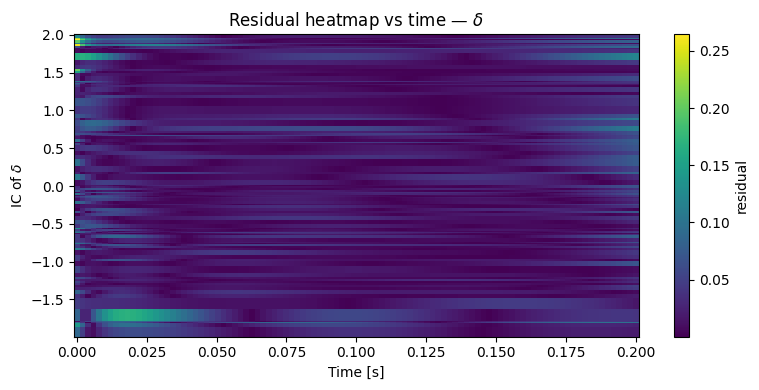

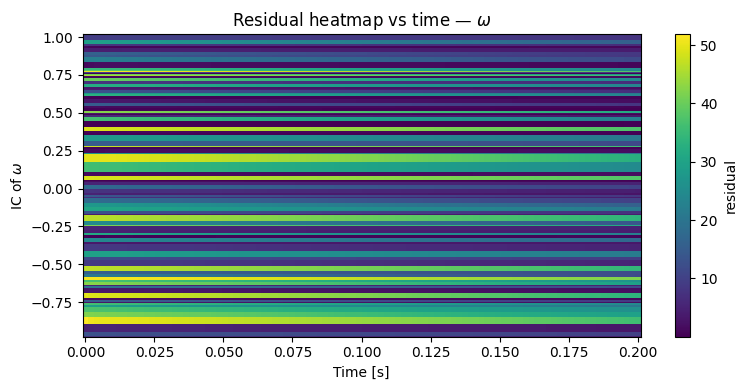

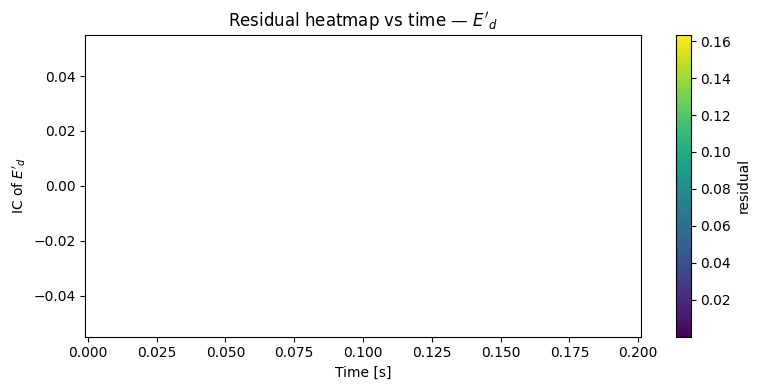

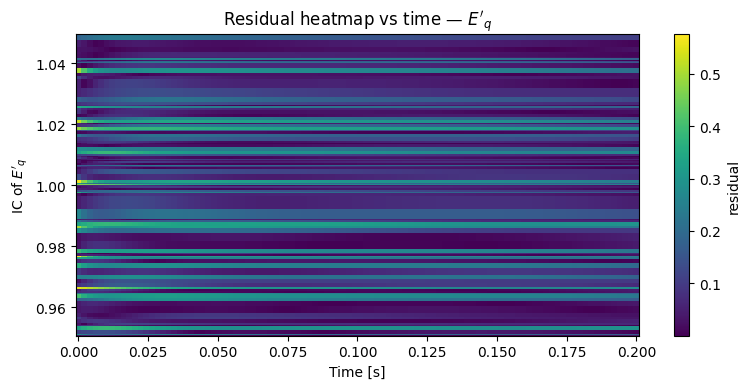

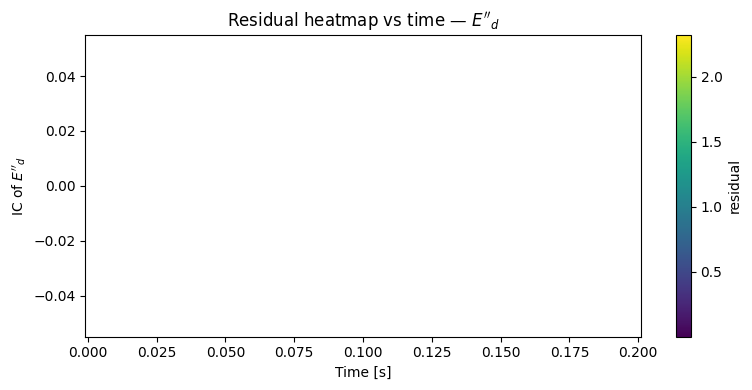

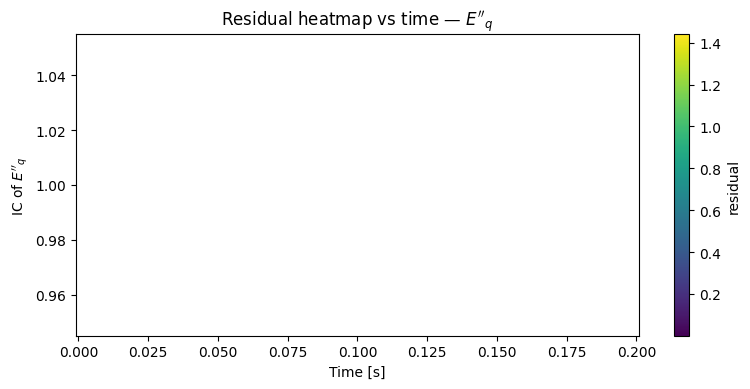

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from pathlib import Path

def pinn_residual_heatmaps_by_state_y(
    solver,                    # your Solver_NN (needs .model, .func, .n_states, .generate_batched_samples)
    bounds,                    # dict with keys for 8 states + 't'
    num_trajectories: int,
    num_points: int,
    *,
    outputs_are_slopes: bool = False,
    state_labels = (r"$\delta$", r"$\omega$", r"$E'_d$", r"$E'_q$", r"$E''_d$", r"$E''_q$"),
    log10: bool = False,
    eps: float = 1e-12,
    save_dir: str | None = None,
):
    """
    Computes residuals r = dy/dt - f(t,y) and plots one heatmap per state:
      x-axis: time, y-axis: IC value of the SAME state, color: residual magnitude.
    Returns (R, y0s): residual tensor (N,T,S) and the IC matrix (N,8).
    """
    def _edges_from_centers(x):
        x = np.asarray(x)
        if x.size == 1:
            return np.array([x[0] - 0.5, x[0] + 0.5])
        mid = 0.5 * (x[:-1] + x[1:])
        first = x[0] - (mid[0] - x[0])
        last  = x[-1] + (x[-1] - mid[-1])
        return np.concatenate(([first], mid, [last]))

    def _time_edges(t0, t1, T):
        t = np.linspace(t0, t1, T)
        if T == 1:
            return np.array([t0 - 0.5, t1 + 0.5])
        mids = 0.5 * (t[:-1] + t[1:])
        left  = t[0]  - (mids[0] - t[0])
        right = t[-1] + (t[-1] - mids[-1])
        return np.concatenate(([left], mids, [right]))

    # ------------------ sample ICs/time exactly once ------------------
    var_names = [k for k in bounds.keys() if k != 't']  # keep your order
    y0s, t_grid = solver.generate_batched_samples(bounds, var_names, num_trajectories, num_points)
    # Model device for autograd; func (machine.forward) will be run on CPU
    model_device = next(solver.model.parameters()).device

    y0s = y0s.to(model_device)
    t_grid = t_grid.to(model_device)

    # Flatten time (enable grad)
    t_vec = t_grid.reshape(-1, 1).clone().detach().requires_grad_(True)     # (N*T,1)
    # Repeat ICs per time step
    y0s_vec = y0s.repeat_interleave(num_points, dim=0)                       # (N*T, 8)

    # Split states/controls
    S = solver.n_states
    y0_states_vec = y0s_vec[:, :S]                                           # (N*T, 6)
    y0_ctrl_vec   = y0s_vec[:, S:] if y0s_vec.shape[1] > S else None         # (N*T, 2) or None
    # print(y0_states_vec,y0_ctrl_vec)
    # ------------------ forward PINN ------------------
    # Model input matches your solve(): [t, y0(8)]
    model_input = torch.cat([t_vec, y0s_vec], dim=1)                         # (N*T, 9)
    solver.model.eval()
    net_out = solver.model(model_input)                                      # (N*T, 6)

    # Reconstruct y(t)
    # if outputs_are_slopes:
    #     y_hat = y0_states_vec + net_out * t_vec                              # slopes -> states
    # else:
    y_hat = net_out                                                      # states directly

    # ------------------ dy/dt (per state) ------------------
    grads = []
    for k in range(S):
        gk = torch.autograd.grad(
            outputs=y_hat[:, k:k+1],
            inputs=t_vec,
            grad_outputs=torch.ones_like(y_hat[:, k:k+1]),
            create_graph=True,
            retain_graph=True #(k < S - 1)
        )[0]                                                                 # (N*T,1)
        grads.append(gk)
    dy_dt = torch.cat(grads, dim=1)                                          # (N*T,6)

    # ------------------ RHS f(t,y) on CPU (robust to device mix) ------------------
    # Detach y and move to CPU for machine.forward(t,y)
    y_hat_cpu   = y_hat.detach().cpu()
    y0_ctrl_cpu = y0_ctrl_vec.detach().cpu() if y0_ctrl_vec is not None else None
    y_full_cpu  = torch.cat([y_hat_cpu, y0_ctrl_cpu], dim=1) if y0_ctrl_cpu is not None else y_hat_cpu
    t_cpu       = t_vec.detach().cpu().squeeze(-1)

    f_list = []
    with torch.no_grad():
        for i in range(y_full_cpu.shape[0]):
            fi = solver.func(t_cpu[i], y_full_cpu[i])                        # (8,)
            f_list.append(fi)
    f_full = torch.stack(f_list, dim=0).to(dy_dt.dtype)                      # (N*T,8) on CPU
    f_val  = f_full[:, :S].to(model_device)                                  # back to model device

    # ------------------ residuals and reshape ------------------
    print(f_val[:,1:2]-dy_dt[:,1:2])
    R = (dy_dt - f_val).view(num_trajectories, num_points, S)                # (N,T,6)
    R_np   = R.detach().cpu().numpy()
    y0s_np = y0s.detach().cpu().numpy()

    # ------------------ plot heatmaps ------------------
    t0, t1 = bounds['t']
    t_edges = _time_edges(t0, t1, num_points)

    if log10:
        Z_title = r"$\log_{10}(|\mathrm{residual}|)$"
    else:
        Z_title = "residual"

    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    for s in range(S):
        # y-axis = IC of state s
        yvals   = y0s_np[:, s]                       # (N,)
        order   = np.argsort(yvals)
        y_sorted= yvals[order]
        Z       = R_np[order, :, s]
        # Zplot =np.abs(Z)
        Zplot   = np.log10(np.abs(Z) + eps) if log10 else np.abs(Z)
        y_edges = _edges_from_centers(y_sorted)

        plt.figure(figsize=(8, 4))
        plt.pcolormesh(t_edges, y_edges, Zplot, shading='auto')
        plt.colorbar(label=Z_title)
        plt.xlabel("Time [s]")
        plt.ylabel(f"IC of {state_labels[s]}")
        plt.title(f"Residual heatmap vs time — {state_labels[s]}")
        plt.tight_layout()
        if save_dir:
            plt.savefig(os.path.join(save_dir, f"residual_heatmap_{s}.png"), dpi=200)
        plt.show()

    return R, y0s_np
bounds_for_sampling= {
    't':(0,0.2),
    'delta'     : (-2,  2),   # rotor angle [rad]
    'omega'     : (-1.0, 1),   # speed deviation [pu]
    'E_d_dash'  : (0.0,   0.0),   # transient d‐axis emf fixed
    'E_q_dash'  : (0.95,   1.05),   # transient q‐axis emf fixed
    'E_d_dd'    : (0.0,   0.0),   # subtransient q‐axis emf fixed
    'E_q_dd'    : (1.0,   1.0),   # subtransient d‐axis emf fixed
    'V_t'       : (0.95,   1.05),   # terminal voltage magnitude [pu]
    'theta_vs'  : (-0.3,  0.3),   # terminal voltage angle [rad]
}
R, y0s = pinn_residual_heatmaps_by_state_y(
    solver=sample_solver_nn,
    bounds=bounds_for_sampling,       # includes 't': (0.0, t_final)
    num_trajectories=100,
    num_points=100,
    outputs_are_slopes=False,         # set True if your net outputs slopes
    save_dir=None                     # or "figs/residuals"
)


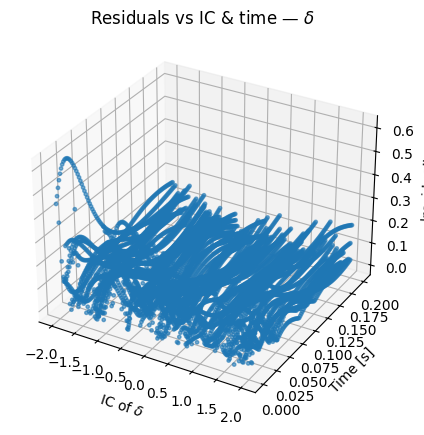

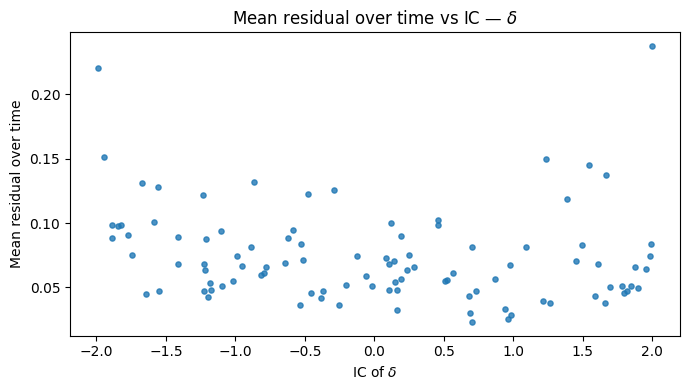

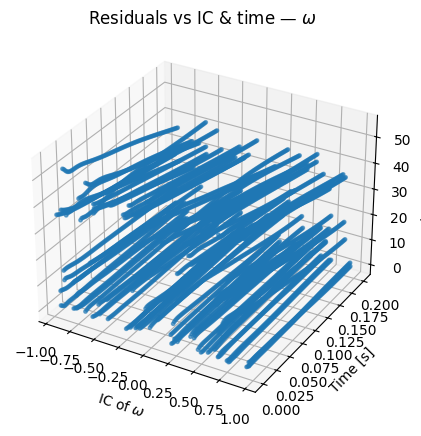

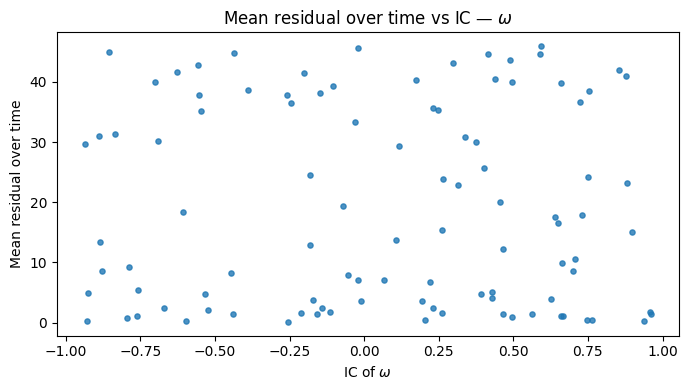

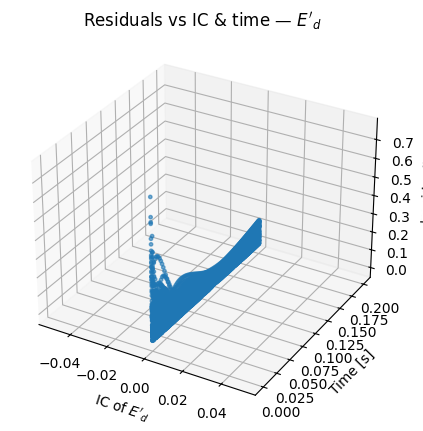

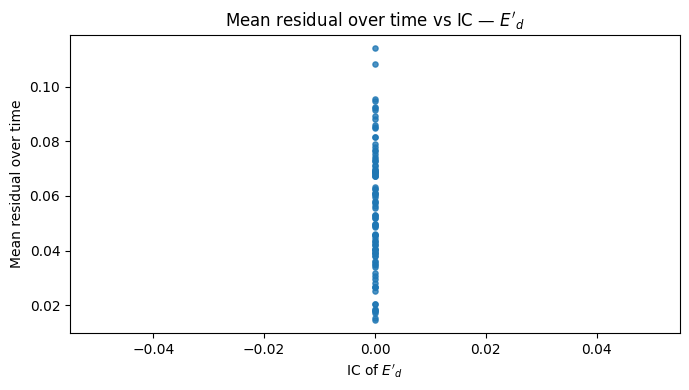

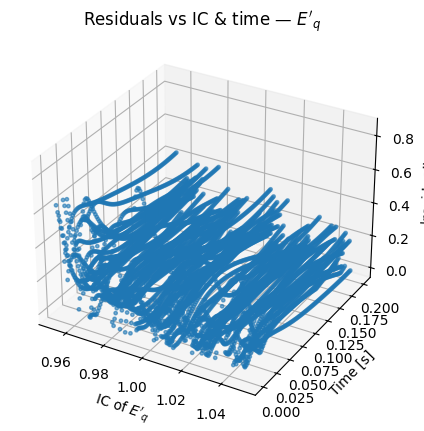

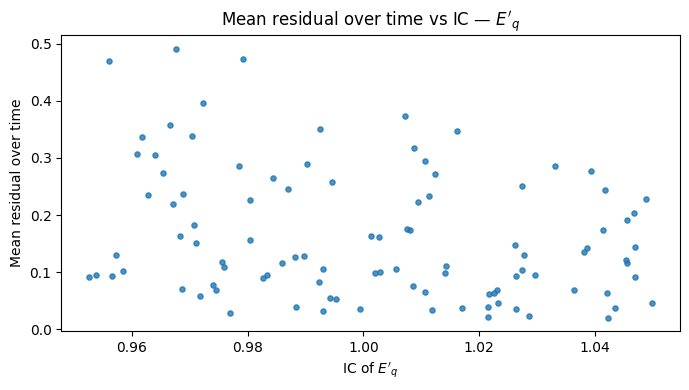

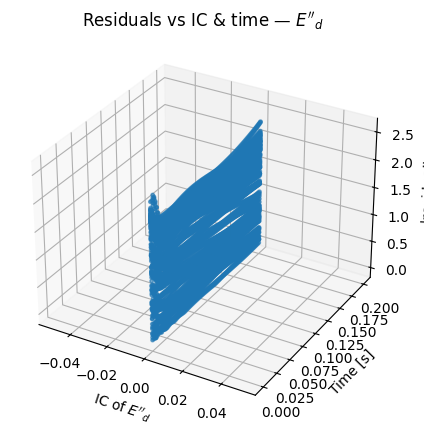

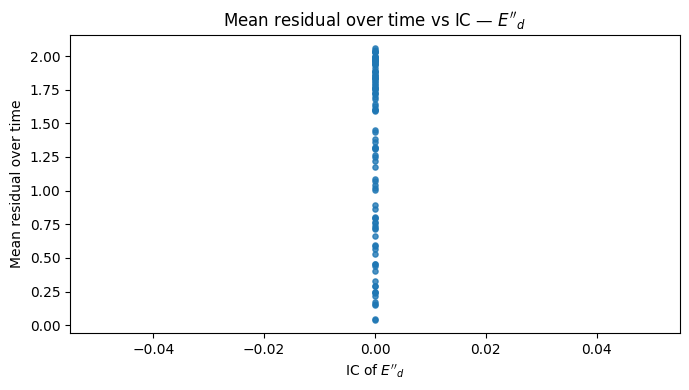

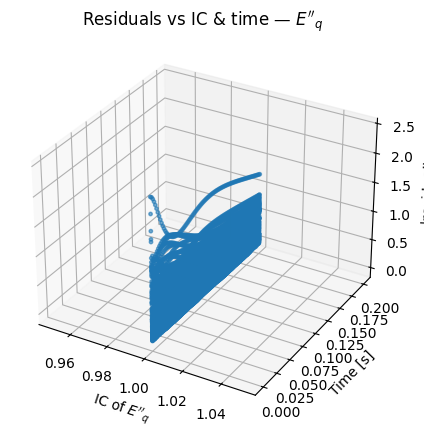

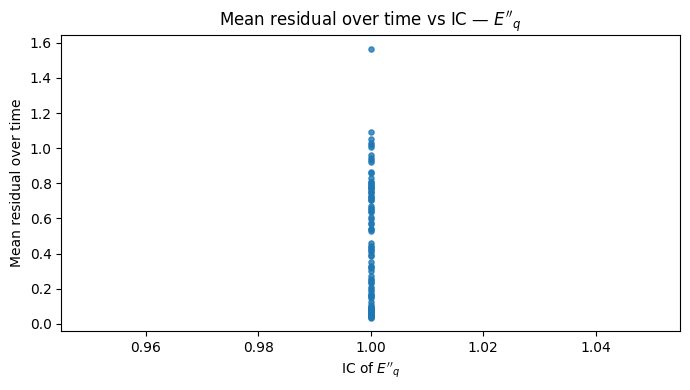

In [40]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (needed for 3D)

def pinn_residual_scatter_vs_ic(
    solver,
    bounds,
    num_trajectories: int,
    num_points: int,
    *,
    outputs_are_slopes: bool = False,   # True if NN outputs dy/dt, else y(t)
    log10: bool = True,
    eps: float = 1e-12,
    save_dir: str | None = None,
    plot_kind: str = "scatter2d",       # "scatter2d" or "scatter3d"
    aggregate: str | None = None,       # None | "mean" | "max" | "l2"  (extra 2D plot)
):
    """
    Compute residuals r = dy/dt - f(t, y[, u]) for a batch of ICs and times, and visualize
    how residuals vary with initial conditions of EACH state.

    - 2D scatter: x=IC(state s), y=time, color=|residual|
    - 3D scatter: x=IC(state s), y=time, z=|residual|

    Returns:
      R:    residuals, shape (N, T, S)
      y0s:  sampled IC/control matrix, shape (N, S + U)
      t:    time vector, shape (T,)
    """
    # ---------- variable order ----------
    if hasattr(solver, "state_names"):
        state_names = list(solver.state_names)
    else:
        var_keys = [k for k in bounds.keys() if k != "t"]
        state_names = var_keys[:solver.n_states]

    if hasattr(solver, "control_names"):
        control_names = list(solver.control_names)
    else:
        var_keys = [k for k in bounds.keys() if k != "t"]
        control_names = var_keys[solver.n_states:]

    var_names = state_names + control_names
    S = solver.n_states

    # ---------- sample ----------
    y0s, t_grid = solver.generate_batched_samples(bounds, var_names, num_trajectories, num_points)
    model_device = next(solver.model.parameters()).device
    y0s = y0s.to(model_device)
    t_grid = t_grid.to(model_device)

    # flatten time; keep grad on t
    t_vec = t_grid.reshape(-1, 1).clone().detach().requires_grad_(True)      # (N*T,1)
    y0s_vec = y0s.repeat_interleave(num_points, dim=0)                        # (N*T, S+U)

    y0_states_vec = y0s_vec[:, :S]
    u_vec = y0s_vec[:, S:] if y0s_vec.shape[1] > S else None

    # ---------- forward (keep graph!) ----------
    solver.model.eval()
    model_input = torch.cat([t_vec, y0s_vec], dim=1)
    net_out = solver.model(model_input)                                       # (N*T, S)

    if outputs_are_slopes:
        # If your model is trained on Δt or normalized time, adjust this factor accordingly.
        y_hat = y0_states_vec + net_out * t_vec
    else:
        y_hat = net_out

    # ---------- dy/dt via autograd ----------
    grads = []
    for k in range(S):
        gk = torch.autograd.grad(
            outputs=y_hat[:, k:k+1],
            inputs=t_vec,
            grad_outputs=torch.ones_like(y_hat[:, k:k+1]),
            create_graph=True,
            retain_graph=True
        )[0]
        grads.append(gk)
    dy_dt = torch.cat(grads, dim=1)                                           # (N*T, S)

    # ---------- RHS f(t, y[, u]) ----------
    t_cpu = t_vec.detach().cpu().squeeze(-1)
    y_cpu = y_hat.detach().cpu()
    u_cpu = u_vec.detach().cpu() if u_vec is not None else None

    f_list = []
    with torch.no_grad():
        for i in range(y_cpu.shape[0]):
            if u_cpu is None:
                fi = solver.func(t_cpu[i], y_cpu[i])
            else:
                try:
                    fi = solver.func(t_cpu[i], y_cpu[i], u_cpu[i])  # preferred signature
                except TypeError:
                    fi = solver.func(t_cpu[i], torch.cat([y_cpu[i], u_cpu[i]], dim=0))
            f_list.append(fi[:S])
    f_val = torch.stack(f_list, dim=0).to(dy_dt)

    # ---------- residuals ----------
    N, T = num_trajectories, num_points
    R = (dy_dt - f_val).view(N, T, S)                                         # (N,T,S)

    # ---------- to numpy for plotting ----------
    R_abs = torch.abs(R).detach().cpu().numpy()
    if log10:
        R_plot = np.log10(R_abs + eps)
        cbar_label = r"$\log_{10}|\mathrm{residual}|$"
    else:
        R_plot = R_abs
        cbar_label = r"$|\mathrm{residual}|$"

    y0s_np = y0s.detach().cpu().numpy()
    t_vals = t_grid[0].detach().cpu().numpy()                                 # (T,)

    # ---------- plotting helpers ----------
    if save_dir:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    label_map = {
        "delta": r"$\delta$", "omega": r"$\omega$",
        "E_d_dash": r"$E'_d$", "E_q_dash": r"$E'_q$",
        "E_d_dd": r"$E''_d$", "E_q_dd": r"$E''_q$",
    }
    state_labels = tuple(label_map.get(n, n) for n in state_names)

    # global color scale for comparability (optional but nice)
    vmin = np.nanpercentile(R_plot, 5)
    vmax = np.nanpercentile(R_plot, 95)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = vmax = None

    for s in range(S):
        ic_vals = y0s_np[:, s]                        # (N,)
        # flatten to N*T points
        X = np.repeat(ic_vals, T)                     # IC repeated along time
        Y = np.tile(t_vals, N)                        # time tiled across ICs
        Z = R_plot[:, :, s].reshape(-1)

        if plot_kind == "scatter3d":
            fig = plt.figure(figsize=(8, 5))
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(X, Y, Z, s=6, alpha=0.6)
            ax.set_xlabel(f"IC of {state_labels[s]}")
            ax.set_ylabel("Time [s]")
            ax.set_zlabel(cbar_label)
            ax.set_title(f"Residuals vs IC & time — {state_labels[s]}")
            if save_dir:
                fig.savefig(Path(save_dir) / f"residual_scatter3d_state{s}.png", dpi=200, bbox_inches='tight')
            plt.show()
        else:
            plt.figure(figsize=(8, 5))
            sc = plt.scatter(X, Y, c=Z, s=8, alpha=0.7, vmin=vmin, vmax=vmax)
            cb = plt.colorbar(sc)
            cb.set_label(cbar_label)
            plt.xlabel(f"IC of {state_labels[s]}")
            plt.ylabel("Time [s]")
            plt.title(f"Residuals vs IC & time — {state_labels[s]}")
            plt.tight_layout()
            if save_dir:
                plt.savefig(Path(save_dir) / f"residual_scatter2d_state{s}.png", dpi=200)
            plt.show()

        # Optional aggregated view: one point per trajectory (IC) summarizing over time
        if aggregate:
            if aggregate == "mean":
                agg = R_plot[:, :, s].mean(axis=1)
                title = "Mean residual over time"
            elif aggregate == "max":
                agg = R_plot[:, :, s].max(axis=1)
                title = "Max residual over time"
            elif aggregate == "l2":
                agg = np.sqrt((R_plot[:, :, s]**2).mean(axis=1))
                title = "L2 residual over time"
            else:
                raise ValueError("aggregate must be None|'mean'|'max'|'l2'")

            plt.figure(figsize=(7, 4))
            plt.scatter(ic_vals, agg, s=14, alpha=0.8)
            plt.xlabel(f"IC of {state_labels[s]}")
            plt.ylabel(title + (" (log10)" if log10 else ""))
            plt.title(f"{title} vs IC — {state_labels[s]}")
            plt.tight_layout()
            if save_dir:
                plt.savefig(Path(save_dir) / f"residual_{aggregate}_vs_ic_state{s}.png", dpi=200)
            plt.show()

    return R, y0s_np, t_vals
bounds_for_sampling = {
    't': (0, 0.2),
    'delta'     : (-2,  2),
    'omega'     : (-1.0, 1),
    'E_d_dash'  : (0.0,   0.0),
    'E_q_dash'  : (0.95,   1.05),
    'E_d_dd'    : (0.0,   0.0),
    'E_q_dd'    : (1.0,   1.0),
    'V_t'       : (0.95,   1.05),
    'theta_vs'  : (-0.3,  0.3),
}

R, y0s, t = pinn_residual_scatter_vs_ic(
    solver=sample_solver_nn,
    bounds=bounds_for_sampling,
    num_trajectories=100,
    num_points=100,
    outputs_are_slopes=False,   # True if NN outputs dy/dt
    log10=False,                 # log color scale tends to be clearer
    save_dir=None,              # or a folder path
    plot_kind="scatter3d",      # or "scatter3d"
    aggregate="mean"            # also try "max" or "l2", or None
)


In [39]:
y0s

array([[ 1.3034484 ,  0.09882808,  0.        , ...,  1.        ,
         1.0078926 ,  0.20193571],
       [-1.2355187 ,  0.11719954,  0.        , ...,  1.        ,
         1.0474932 , -0.1344506 ],
       [-1.7772071 , -0.5981866 ,  0.        , ...,  1.        ,
         1.0408026 , -0.13606071],
       ...,
       [-0.450186  , -0.50832534,  0.        , ...,  1.        ,
         0.96961856, -0.03987896],
       [ 1.6923239 , -0.7370213 ,  0.        , ...,  1.        ,
         1.0467942 ,  0.05628791],
       [ 0.60667634,  0.55278444,  0.        , ...,  1.        ,
         1.0376488 , -0.01045111]], dtype=float32)

In [ ]:
f_full

In [38]:
R

tensor([[[-1.6740e-01,  2.3608e+01, -1.4340e-01, -3.8959e-01,  2.1470e+00,
          -4.8814e-01],
         [-1.4286e-01,  2.3418e+01, -9.3177e-02, -3.4076e-01,  2.0143e+00,
          -6.1721e-01],
         [-1.2277e-01,  2.3330e+01, -5.2375e-02, -3.0230e-01,  1.9069e+00,
          -7.1082e-01],
         ...,
         [-8.4163e-02,  1.5972e+01, -9.4445e-02, -2.0718e-03,  1.4685e+00,
          -2.9606e-01],
         [-8.3290e-02,  1.5890e+01, -9.7044e-02, -6.7287e-03,  1.4642e+00,
          -2.9319e-01],
         [-8.2380e-02,  1.5807e+01, -9.9649e-02, -1.1352e-02,  1.4599e+00,
          -2.9027e-01]],

        [[-5.1685e-02, -1.9878e+01,  1.2835e-01,  4.6816e-01, -1.7306e+00,
          -9.7545e-02],
         [-1.0635e-01, -2.0269e+01,  6.5479e-02,  4.6847e-01, -1.8352e+00,
           1.4213e-02],
         [-1.2884e-01, -2.0411e+01,  2.5382e-02,  4.6072e-01, -1.8539e+00,
           4.3357e-02],
         ...,
         [ 3.5644e-02, -1.1314e+01,  4.1380e-02,  7.0738e-02, -1.5608e+00,
    